#  Pipeline NLP — Code de la Route Marocain (Loi 52-05)
**Devoir 1 — M1 MIASD, FSTT**

---

## Vue d'ensemble du pipeline

```
PDF brut  ──►  [A] Normalisation arabe  ──►  Segmentation en articles
                                                        │
                                          ┌─────────────┴─────────────┐
                                          │                           │
                                  [B] Extraction                [C] ML
                               par règles (Regex)          TF-IDF + KMeans
                               type / amende / permis      + Naive Bayes
                                          │                           │
                                          └─────────────┬─────────────┘
                                                        │
                                               DataFrame + Export CSV
                                               + Visualisations enrichies
```

> **Note :** Toutes les étapes sont reproduites **fidèlement** ; seules la mise en forme du code, les commentaires et les graphiques ont été enrichis.


##  Installation des dépendances

In [1]:
# Toutes les bibliothèques nécessaires au pipeline
# pyarabic  → normalisation du texte arabe (tashkeel, hamza …)
# pypdf     → extraction du texte d'un PDF page par page
# scikit-learn → TF-IDF, KMeans, Naive Bayes, cross-validation
!pip install pyarabic pypdf scikit-learn pandas seaborn -q


##  Imports

In [2]:
import re
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Arabe
from pyarabic.araby import strip_tashkeel

# PDF
from pypdf import PdfReader

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster            import KMeans
from sklearn.naive_bayes        import MultinomialNB
from sklearn.preprocessing      import LabelEncoder
from sklearn.model_selection    import cross_val_score
from sklearn.metrics            import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition      import TruncatedSVD   # pour visualiser les clusters en 2D

# Style Seaborn global (améliore tous les graphiques matplotlib)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13})

print(" Imports OK")


 Imports OK


---
##  Étape A — Prétraitement du texte arabe

**Objectif :** Nettoyer le texte brut extrait du PDF pour que les patterns regex fonctionnent de façon fiable.

| Opération | Avant | Après |
|---|---|---|
| Tashkeel (voyelles courtes) | يُعَاقَبُ | يعاقب |
| Hamza initiale | أحكام / إحكام / آخر | احكام / احكام / اخر |
| Hamza médiane | ؤ → و , ئ → ي | normalisé |
| Ta Marbuta | غرامة | غرامه |
| Alif Maqsura | ى | ي |
| Chiffres arabes orientaux | ١٠٠٠ | 1000 |
| Caractères BIDI invisibles | ‎‏ … | supprimés |


###  Extraction du texte PDF

In [3]:
# ── Chemin vers le PDF (adapter selon votre environnement Kaggle / local) ──
PDF_PATH = "/kaggle/input/datasets/medaymanelkajdouhi/code-route-maroc-nlp/code de la route MA52_05.pdf"

def extract_pdf_text(pdf_path: str) -> str:
    """
    Lit chaque page du PDF et concatène le texte brut.
    Retourne une seule grande chaîne de caractères.
    """
    reader = PdfReader(pdf_path)
    pages_text = []
    for page in reader.pages:
        t = page.extract_text()
        if t:                       # certaines pages peuvent être vides / images
            pages_text.append(t)
    return "\n".join(pages_text)

raw_text = extract_pdf_text(PDF_PATH)

print(f" Texte extrait : {len(raw_text):,} caractères sur {raw_text.count(chr(10)):,} lignes")
print(f"\n Aperçu (500 premiers caractères) :\n{'─'*60}")
print(raw_text[:500])


 Texte extrait : 216,951 caractères sur 3,818 lignes

 Aperçu (500 premiers caractères) :
────────────────────────────────────────────────────────────
تم إعداد هذه النسخة من أجل تسهيل 
مقروئية النص، ولا يحتج إلا بالنصوص 
في صيغتها المنشورة بالجريدة الرسمية
 المتعلق 52.05القانون رقم 
بمدونة السير على الطرق، 
كما وقع تغييره وتتميمه 
صيغة موطدة بتاريخ 
2024يوليو10
1
الأمانة العامة للحكومة
 52.05القانون رقم 
 1.10.07المتعلق بمدونة السير على الطرق الصادر بتنفيذه الظهير الشريف رقم 
)،2010 فبراير11( 1431 من صفر26بتاريخ 
كما وقع تغييره وتتميمه
)2168)، ص2010 مارس25( 1431 ربيع الآخر8 بتاريخ5824ج.ر عدد(
لكتاب الأولا
شروط السير على الطريق العمومية
القسم ا


###  Normalisation du texte arabe

In [4]:
# ── Patterns précompilés (pour la performance) ────────────────────────────
BIDI_CHARS_RE = re.compile(r'[\u200B-\u200F\u202A-\u202E\u2066-\u2069\uFEFF]')

# Table de traduction : chiffres arabes orientaux → chiffres latins (0-9)
ARABIC_DIGITS_TRANS = str.maketrans(
    '\u0660\u0661\u0662\u0663\u0664\u0665\u0666\u0667\u0668\u0669',
    '0123456789'
)

def normalize_arabic(text: str) -> str:
    """
    Normalisation complète en 8 étapes :
      1. Suppression BIDI (caractères directionnels invisibles)
      2. Suppression Tashkeel (voyelles : fatha, damma, kasra, shadda…)
      3. Suppression Tatweel ـ (trait d'allongement décoratif)
      4. Normalisation Hamza initiale : أ إ آ  →  ا
      5. Normalisation Hamza médiane  : ؤ→و   ئ→ي
      6. Normalisation Ta Marbuta     : ة→ه   et Alif Maqsura : ى→ي
      7. Conversion chiffres arabes orientaux → latins
      8. Nettoyage espaces/sauts de ligne multiples
    """
    text = BIDI_CHARS_RE.sub('', text)                          # étape 1
    text = strip_tashkeel(text)                                  # étape 2
    text = text.replace('\u0640', '')                            # étape 3 : tatweel ـ
    text = re.sub(r'[\u0623\u0625\u0622]', '\u0627', text)    # étape 4 : أ إ آ → ا
    text = text.replace('\u0624', '\u0648')                      # étape 5a : ؤ → و
    text = text.replace('\u0626', '\u064A')                      # étape 5b : ئ → ي
    text = text.replace('\u0629', '\u0647')                      # étape 6a : ة → ه
    text = text.replace('\u0649', '\u064A')                      # étape 6b : ى → ي
    text = text.translate(ARABIC_DIGITS_TRANS)                   # étape 7
    text = re.sub(r'[ \t]+', ' ', text)                         # étape 8a
    text = re.sub(r'\n{3,}', '\n\n', text)                    # étape 8b
    return text

clean_text = normalize_arabic(raw_text)

print(f" Normalisation terminée")
print(f"   Avant : {len(raw_text):,} caractères → Après : {len(clean_text):,} caractères")
print(f"   Réduction : {100*(1 - len(clean_text)/len(raw_text)):.1f}%")

# ── Démonstration avant / après ──────────────────────────────────────────
demo_phrases = [
    "يُعَاقَبُ بِغَرَامَةٍ مِنْ أَلْفٍ (1.000) إِلَى أَلْفَيْنِ (2.000) دِرْهَمٍ",
    "يَجِبُ عَلَى كُلِّ سَائِقٍ أَنْ يَحْمِلَ رُخْصَةَ السِّيَاقَةِ",
]
print("\n Démonstration normalisation :")
print(f"{'─'*70}")
for demo in demo_phrases:
    print(f"  ➤ Avant : {demo}")
    print(f"  ➤ Après : {normalize_arabic(demo)}")
    print()


 Normalisation terminée
   Avant : 216,951 caractères → Après : 216,834 caractères
   Réduction : 0.1%

 Démonstration normalisation :
──────────────────────────────────────────────────────────────────────
  ➤ Avant : يُعَاقَبُ بِغَرَامَةٍ مِنْ أَلْفٍ (1.000) إِلَى أَلْفَيْنِ (2.000) دِرْهَمٍ
  ➤ Après : يعاقب بغرامه من الف (1.000) الي الفين (2.000) درهم

  ➤ Avant : يَجِبُ عَلَى كُلِّ سَائِقٍ أَنْ يَحْمِلَ رُخْصَةَ السِّيَاقَةِ
  ➤ Après : يجب علي كل سايق ان يحمل رخصه السياقه



---
##  Segmentation — Découpage en articles

Chaque article commence par le pattern **`(\d+)الماده`** (ex : `1الماده` = Article 1).

> **Note :** Le numéro apparaît *avant* le mot arabe dans le texte extrait du PDF,  
> car pypdf lit les tokens en ordre logique (gauche→droite) même en contexte RTL.

On associe également chaque article à sa **position hiérarchique** dans le document :
`Livre → Section → Titre → Chapitre`


###  Segmentation en articles avec contexte hiérarchique

In [5]:
# Pattern principal : détecte "NUMالماده" (ex : "37الماده")
ARTICLE_HEADER_RE = re.compile(r'(\d+)الماده\b')

# Patterns pour les divisions du document (livre, section, titre, chapitre/fre')
CHAPTER_PATTERNS = [
    (re.compile(r'(الكتاب\s+(?:الاول|الثاني|الثالث|الرابع|الخامس))'),      'livre'),
    (re.compile(r'(القسم\s+(?:الاول|الثاني|الثالث|الرابع|الخامس))'),       'section'),
    (re.compile(r'(الباب\s+(?:الاول|الثاني|الثالث|الرابع|الخامس|السادس|السابع|الثامن|التاسع|العاشر))'), 'titre'),
    (re.compile(r'(\d+)\s*الفرع'),                                          'chapitre'),
]

def segment_articles_with_chapters(text: str) -> list[dict]:
    """
    Découpe le texte normalisé en articles individuels.
    Pour chaque article, enregistre :
      - article_id  : identifiant numérique
      - raw_text    : corps de l'article
      - chapitre    : hiérarchie Livre / Section / Titre / Chapitre

    Algorithme :
      1. Indexer toutes les marques de chapitre (position dans le texte)
      2. Trouver tous les débuts d'article (dédupliqués, 1 ≤ id ≤ 400)
      3. Pour chaque article, remonter les marques de chapitre antérieures
    """
    # 1 — Positions des en-têtes de chapitre
    chapter_positions = []
    for pat, level in CHAPTER_PATTERNS:
        for m in pat.finditer(text):
            chapter_positions.append((m.start(), level, m.group()))
    chapter_positions.sort(key=lambda x: x[0])

    # 2 — Débuts d'articles uniques, triés, dans la plage 1-400
    matches = list(ARTICLE_HEADER_RE.finditer(text))
    seen_ids = set()
    unique_matches = []
    for m in matches:
        aid = int(m.group(1))
        if aid not in seen_ids and 1 <= aid <= 400:
            seen_ids.add(aid)
            unique_matches.append(m)

    # 3 — Construction des enregistrements
    articles = []
    cur = {"livre": "", "section": "", "titre": "", "chapitre": ""}

    for i, m in enumerate(unique_matches):
        art_pos = m.start()

        # Mise à jour du contexte hiérarchique courant
        for pos, level, label in chapter_positions:
            if pos < art_pos:
                cur[level] = label.strip()
                if level == 'livre':
                    cur['section'] = cur['titre'] = cur['chapitre'] = ""
                elif level == 'section':
                    cur['titre'] = cur['chapitre'] = ""
                elif level == 'titre':
                    cur['chapitre'] = ""

        parts = [v for v in [cur['livre'], cur['section'], cur['titre'], cur['chapitre']] if v]
        body_start = m.end()
        body_end   = unique_matches[i + 1].start() if i + 1 < len(unique_matches) else len(text)

        articles.append({
            "article_id": int(m.group(1)),
            "raw_text":   text[body_start:body_end].strip(),
            "chapitre":   " / ".join(parts) if parts else None,
        })

    return articles

articles = segment_articles_with_chapters(clean_text)

print(f" {len(articles)} articles détectés")
print(f"   Premier article : Article {articles[0]['article_id']}")
print(f"   Dernier article : Article {articles[-1]['article_id']}")
print(f"\n Exemple — Article {articles[0]['article_id']} :")
print(f"   Chapitre : {articles[0]['chapitre']}")
print(f"   Texte    : {articles[0]['raw_text'][:250]}…")


 318 articles détectés
   Premier article : Article 1
   Dernier article : Article 318

 Exemple — Article 1 :
   Chapitre : القسم الاول / الباب الاول
   Texte    : لا يجوز لاي شخص ان يسوق مركبه ذات محرك او مجموعه مركبات علي الطريق العموميه 
ما لم يكن حاصلا علي رخصه للسياقه ساريه الصلاحيه ومسلمه من قبل الاداره، تناسب صنف 
المركبه او مجموعه المركبات التي يسوقها.…


---
##  Étape B — Extraction par règles (Rules-based NLP)

On utilise des **expressions régulières** et des **lexiques de mots-clés**  
pour extraire des entités juridiques directement depuis le texte arabe.

| Extracteur | Entité recherchée | Technique |
|---|---|---|
| `type_paragraphe` | Rôle sémantique de l'article | Mots marqueurs (يعاقب, يمنع…) |
| `amende_fixe` | Montant en dirhams | Regex `(\d+)\s*درهم` |
| `points_retrait` | Points retirés | Regex `خصم\s+(\d+)\s*نقط` |
| `categorie_permis` | Catégorie AM/A1/B/C/D/E(B) | 3 patterns combinés |
| `categorie_vehicule` | Type de véhicule | Lexique 8 catégories |
| `mots_cles` | Tags thématiques | Lexique 25 thèmes |
| `sanction_type` | Nature de la sanction | Lexique 7 types |
| `loi_reference` | Référence législative | Regex `رقم\s*[\d.]+` |
| `source_article` | Renvois inter-articles | Regex `الماده\s*(\d+)` |


### B.1 — Classificateur de type de paragraphe (règles)

In [6]:
def extract_type_paragraphe(text: str) -> str:
    """
    Classifie le rôle sémantique d'un article selon les mots marqueurs présents.
    Priorité décroissante : sanction > interdiction > obligation > définition
                          > exception > procédure > disposition générale.

    Exemples de marqueurs :
      يعاقب  = « est puni »        → sanction
      يمنع   = « est interdit »    → interdiction
      يجب    = « il faut »         → obligation
      يقصد   = « on entend par »   → définition
    """
    if any(m in text for m in ('يعاقب', 'غرامه', 'الحبس', 'عقوبه')):
        return "sanction"
    if any(m in text for m in ('يمنع', 'يحظر', 'لا يجوز')):
        return "interdiction"
    if any(m in text for m in ('يجب', 'يتعين', 'يلزم', 'وجوبا')):
        return "obligation"
    if any(m in text for m in ('يقصد', 'يراد ب', 'يراد في مفهوم')):
        return "definition"
    if any(m in text for m in ('استثناء', 'غير ان', 'خلافا')):
        return "exception"
    if any(m in text for m in ('تحدد', 'تضع الاداره', 'يحدد بنص تنظيمي')):
        return "procedure"
    return "disposition_generale"

# ── Test sur les 5 premiers articles ────────────────────────────────────────
print(" Test extract_type_paragraphe (articles 1–5) :")
for a in articles[:5]:
    t = extract_type_paragraphe(a['raw_text'])
    print(f"  Article {a['article_id']:3d} → {t}")


 Test extract_type_paragraphe (articles 1–5) :
  Article   1 → interdiction
  Article   2 → exception
  Article   3 → obligation
  Article   4 → disposition_generale
  Article   5 → exception


### B.2 — NER : Catégories de permis de conduire

In [7]:
def extract_categorie_permis(text: str) -> str | None:
    """
    Détecte les catégories de permis (AM, A1, B, C, D, E(B)…).
    
    Trois patterns sont nécessaires car pypdf peut extraire la même catégorie
    sous des formes différentes selon l'orientation droite-à-gauche du PDF :
      Pattern 1 : E)D / E)C / E)B / AM / A1    (format pypdf inversé)
      Pattern 2 : صنف B  ou  الصنف B            (texte arabe direct)
      Pattern 3 : )B( ou B)                      (parenthèses inversées)
    """
    found = set()

    # Pattern 1 — formats pypdf inversés
    for m in re.finditer(r'E\)D|E\)C|E\)B|AM|A1', text):
        val = m.group()
        if val.startswith('E)'):
            val = f"E({val[2:]})"   # E)B  →  E(B)
        found.add(val)

    # Pattern 2 — صنف + lettre
    for m in re.finditer(r'(?:صنف|الصنف)\s*\(?\s*([ABCD])\b', text):
        found.add(m.group(1))

    # Pattern 3 — lettre entre parenthèses
    for m in re.finditer(r'\)\s*([ABCD])\s*\(|([ABCD])\s*\)', text):
        letter = m.group(1) or m.group(2)
        if letter:
            found.add(letter)

    return ";".join(sorted(found)) if found else None

result = extract_categorie_permis(articles[6]['raw_text'])
print(f" Article 7 → categorie_permis = {result}")


 Article 7 → categorie_permis = A;A1;AM;B;C;D;E(B);E(C);E(D)


### B.3 — Extraction des montants d'amende (en dirhams)

In [8]:
# pypdf extrait parfois les parenthèses en ordre inversé à cause du RTL
AMOUNT_PAREN_RE  = re.compile(r'([\d.,]+)\s*\)')      # ex: "500)" dans le PDF
AMOUNT_INLINE_RE = re.compile(r'([\d.,]+)\s*درهم')     # ex: "500 درهم"

def _parse_amount(s: str) -> int | None:
    """Convertit une chaîne de montant '1.000' ou '1,000' en entier 1000.
    Retourne None si la valeur est inférieure à 100 DH (vraisemblablement
    un autre nombre, pas une amende).
    """
    s = s.replace('.', '').replace(',', '').replace(' ', '')
    try:
        val = int(s)
        return val if val >= 100 else None
    except ValueError:
        return None

def extract_amende(text: str) -> str | None:
    """
    Double stratégie de détection :
      Passe 1 : cherche un nombre suivi de ')' dans une fenêtre contenant 'درهم'
      Passe 2 : fallback direct  'NUM درهم'
    Retourne les montants triés et dédupliqués, séparés par ';'.
    """
    amounts = []

    # Passe 1 — format pypdf inversé
    for m in AMOUNT_PAREN_RE.finditer(text):
        window = text[max(0, m.start() - 100): m.end() + 100]
        if 'درهم' in window and 'نق' not in text[m.end(): m.end() + 30]:
            val = _parse_amount(m.group(1))
            if val:
                amounts.append(val)

    # Passe 2 — fallback format direct
    if not amounts:
        for m in AMOUNT_INLINE_RE.finditer(text):
            val = _parse_amount(m.group(1))
            if val:
                amounts.append(val)

    if not amounts:
        return None
    return ";".join(str(a) for a in sorted(set(amounts)))

# ── Afficher les 10 premiers articles avec amende détectée ──────────────────
print(" Échantillon — Articles avec amende détectée :")
count = 0
for a in articles:
    r = extract_amende(a['raw_text'])
    if r:
        print(f"  Article {a['article_id']:3d} → {r} DH")
        count += 1
        if count >= 10:
            break
print(f"  (… {sum(1 for a in articles if extract_amende(a['raw_text']))} articles au total)")


 Échantillon — Articles avec amende détectée :
  Article 126 → 5000 DH
  Article 143 → 12000 DH
  Article 148 → 4000;20000 DH
  Article 150 → 5000 DH
  Article 151 → 2000 DH
  Article 152 → 4000;5882;6490;8000 DH
  Article 154 → 1200 DH
  Article 155 → 1437;5000;5872;6490 DH
  Article 156 → 30000 DH
  Article 157 → 30000 DH
  (… 51 articles au total)


### B.4 — Extraction des points de retrait

In [9]:
# Trois patterns pour couvrir les variantes orthographiques du PDF
POINTS_RETRAIT_PATTERNS = [
    re.compile(r'خصم\s*(\d+)\s*نقط'),                       # خصم 4 نقط
    re.compile(r'(\d+)\s*\)\s*نقط'),                        # 4) نقط  (format pypdf)
    re.compile(r'(\d+)\s*نقط\s*من\s*(?:رخصه|رصيد)'),       # 4 نقط من رخصه
]

def extract_points_retrait(text: str) -> int | None:
    """
    Retourne le nombre de points retirés (entre 1 et 14).
    Les points par infraction figurent dans un tableau annexe réglementaire ;
    ils n'apparaissent donc que rarement dans le corps des articles.
    """
    for pat in POINTS_RETRAIT_PATTERNS:
        m = pat.search(text)
        if m:
            val = int(m.group(1))
            if 1 <= val <= 14:
                return val
    return None

total_pts = sum(1 for a in articles if extract_points_retrait(a['raw_text']))
print(f" Points retrait : {total_pts} / {len(articles)} articles concernés")


 Points retrait : 0 / 318 articles concernés


### B.5 à B.9 — Lexiques thématiques et extracteurs complémentaires

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
#  B.5 — Catégories de véhicules
# ══════════════════════════════════════════════════════════════════════════════
VEHICLE_LEXICON = {
    "poids_lourd":            ["شاحن", "وزن اجمالي", "مقطوره"],
    "transport_commun":       ["حافل", "نقل عمومي", "النقل الجماعي"],
    "moto":                   ["دراجه ناريه", "دراجه بمحرك", "دراجه ذات محرك"],
    "vehicule_leger":         ["سياره", "مركبه خفيفه"],
    "taxi":                   ["سياره اجره", "طاكسي"],
    "transport_marchandises": ["نقل البضايع", "نقل السلع"],
    "matieres_dangereuses":   ["مواد خطره", "المواد الخطره"],
    "vehicule_agricole":      ["مركبه فلاحيه", "اريبه", "غابويه"],
}

def extract_categorie_vehicule(text: str) -> str | None:
    found = [k for k, terms in VEHICLE_LEXICON.items() if any(t in text for t in terms)]
    return ";".join(found) if found else None

# ══════════════════════════════════════════════════════════════════════════════
#  B.6 — Mots-clés thématiques (25 thèmes)
# ══════════════════════════════════════════════════════════════════════════════
MOTS_CLES_LEXICON = {
    "vitesse":            ["السرعه", "تجاوز السرعه", "سرعه مفرطه", "كلم في الساعه"],
    "stationnement":      ["وقوف", "توقف", "الركن"],
    "alcool":             ["كحول", "مشروبات كحوليه", "حاله سكر"],
    "drogue":             ["مخدرات", "مواد مخدره"],
    "telephone":          ["الهاتف", "هاتف"],
    "ceinture":           ["حزام السلامه", "حزام الامان"],
    "casque":             ["خوذه"],
    "feu_rouge":          ["الضوء الاحمر", "اشاره الضوء"],
    "depassement":        ["التجاوز"],
    "document_invalide":  ["رخصه منتهيه", "رخصه مزوره", "تزوير"],
    "delit_fuite":        ["الفرار", "ترك مكان الحادثه"],
    "accident":           ["حادثه سير", "جروح", "وفاه"],
    "recidive":           ["العود", "حاله العود"],
    "permis":             ["رخصه السياقه", "رخصه سياقه"],
    "periode_probatoire": ["الفتره الاختباريه", "فتره اختباريه"],
    "aptitude_medicale":  ["فحص طبي", "اهليه بدنيه", "شهاده طبيه"],
    "points":             ["النقط", "رصيد النقط", "خصم النقط"],
    "immatriculation":    ["التسجيل", "شهاده التسجيل", "صفايح"],
    "controle_technique": ["مراقبه تقنيه", "المراقبه التقنيه"],
    "assurance":          ["التامين", "تامين"],
    "chargement":         ["الحموله", "الشحن", "البضايع"],
    "priorite":           ["الاسبقيه", "حق الاسبقيه", "اولويه المرور"],
    "eclairage":          ["الاناره", "الاضواء", "المصابيح"],
    "signalisation":      ["علامات", "اشاره", "التشوير"],
    "nuit":               ["الليل", "في الليل", "المصابيح الاماميه"],
    "autoroute":          ["الطريق السيار", "الطرق السياره"],
}

def extract_mots_cles(text: str) -> str | None:
    found = [k for k, terms in MOTS_CLES_LEXICON.items() if any(t in text for t in terms)]
    return ";".join(found) if found else None

# ══════════════════════════════════════════════════════════════════════════════
#  B.7 — Type de sanction
# ══════════════════════════════════════════════════════════════════════════════
SANCTION_LEXICON = {
    "amende":            ["غرامه", "الغرامه", "درهم"],
    "retrait_permis":    ["سحب رخصه", "توقيف رخصه", "سحب الرخصه"],
    "annulation_permis": ["تلغي رخصه", "الغاء رخصه", "تلغي الرخصه"],
    "prison":            ["الحبس", "السجن"],
    "retrait_points":    ["خصم النقط", "تخفيض رصيد"],
    "confiscation":      ["حجز المركبه", "مصادره"],
    "immobilisation":    ["توقيف المركبه"],
}

def extract_sanction_type(text: str) -> str | None:
    found = [lbl for lbl, kws in SANCTION_LEXICON.items() if any(kw in text for kw in kws)]
    return ";".join(found) if found else None

# ══════════════════════════════════════════════════════════════════════════════
#  B.8 — Références législatives
# ══════════════════════════════════════════════════════════════════════════════
LOI_REF_RE = re.compile(r'رقم\s*([\d.]+)')

def extract_loi_reference(text: str) -> str | None:
    # On filtre les références courtes (< 4 chars) pour éviter les faux positifs
    refs = {
        f"Loi {m.group(1)}"
        for m in LOI_REF_RE.finditer(text)
        if '.' in m.group(1) and len(m.group(1)) >= 4
    }
    return ";".join(sorted(refs)) if refs else None

# ══════════════════════════════════════════════════════════════════════════════
#  B.9 — Renvois inter-articles
# ══════════════════════════════════════════════════════════════════════════════
def extract_source_article(text: str, current_id: int) -> str | None:
    refs = set()
    # Référence simple : الماده N
    for m in re.finditer(r'الماده\s*(\d+)', text):
        ref_id = int(m.group(1))
        if ref_id != current_id and 1 <= ref_id <= 400:
            refs.add(ref_id)
    # Référence double : المادتين N و M
    for m in re.finditer(r'المادتين\s*(\d+)\s*و\s*(\d+)', text):
        for g in m.groups():
            ref_id = int(g)
            if ref_id != current_id and 1 <= ref_id <= 400:
                refs.add(ref_id)
    return ";".join(str(r) for r in sorted(refs)) if refs else None

print(" Tous les extracteurs B.5 → B.9 définis")


 Tous les extracteurs B.5 → B.9 définis


###  Construction du DataFrame (Étape B complète)

In [11]:
def build_record(article: dict) -> dict:
    """
    Applique l'ensemble des extracteurs sur un article et retourne
    un dictionnaire prêt à être intégré dans le DataFrame.
    """
    text = article["raw_text"]
    # Première phrase comme description courte de l'infraction
    desc = re.split(r'[.;\u061B]\s+', text, maxsplit=2)
    return {
        "article_id":         article["article_id"],
        "infraction_desc":    (desc[0] + '.' if desc else text[:200])[:300],
        "type_paragraphe":    extract_type_paragraphe(text),
        "categorie_vehicule": extract_categorie_vehicule(text),
        "amende_fixe":        extract_amende(text),
        "points_retrait":     extract_points_retrait(text),
        "mots_cles":          extract_mots_cles(text),
        "categorie_permis":   extract_categorie_permis(text),
        "sanction_type":      extract_sanction_type(text),
        "loi_reference":      extract_loi_reference(text),
        "source_article":     extract_source_article(text, article["article_id"]),
        "chapitre":           article.get("chapitre"),
        "texte_complet":      text,
    }

# ── Application sur tous les articles ───────────────────────────────────────
records = [build_record(a) for a in articles]
df = (pd.DataFrame(records)
        .drop_duplicates("article_id")
        .sort_values("article_id")
        .reset_index(drop=True))

print(f" DataFrame créé : {df.shape[0]} lignes × {df.shape[1]} colonnes\n")

# ── Statistiques de remplissage ──────────────────────────────────────────────
print("STATISTIQUES DE REMPLISSAGE — Étape B")
print("=" * 55)
skip_cols = ('texte_complet', 'infraction_desc')
for col in df.columns:
    if col in skip_cols:
        continue
    if df[col].dtype == object:
        n = ((df[col].notna()) & (df[col] != '') & (df[col] != 'None')).sum()
    else:
        n = df[col].notna().sum()
    pct = 100 * n / len(df)
    bar = '█' * int(pct / 2) + '░' * (50 - int(pct / 2))
    print(f"  {col:22s} : {n:3d}/{len(df)} ({pct:5.1f}%) {bar[:25]}")


 DataFrame créé : 318 lignes × 13 colonnes

STATISTIQUES DE REMPLISSAGE — Étape B
  article_id             : 318/318 (100.0%) █████████████████████████
  type_paragraphe        : 318/318 (100.0%) █████████████████████████
  categorie_vehicule     :  32/318 ( 10.1%) █████░░░░░░░░░░░░░░░░░░░░
  amende_fixe            :  51/318 ( 16.0%) ████████░░░░░░░░░░░░░░░░░
  points_retrait         :   0/318 (  0.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░
  mots_cles              : 214/318 ( 67.3%) █████████████████████████
  categorie_permis       :   8/318 (  2.5%) █░░░░░░░░░░░░░░░░░░░░░░░░
  sanction_type          : 112/318 ( 35.2%) █████████████████░░░░░░░░
  loi_reference          :  89/318 ( 28.0%) █████████████░░░░░░░░░░░░
  source_article         :  47/318 ( 14.8%) ███████░░░░░░░░░░░░░░░░░░
  chapitre               : 318/318 (100.0%) █████████████████████████


###  Aperçu des résultats — Étape B

In [12]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 45)

# Distribution des types de paragraphe
print(" DISTRIBUTION — type_paragraphe")
print("=" * 45)
vc = df['type_paragraphe'].value_counts()
for val, cnt in vc.items():
    bar = '▓' * cnt
    print(f"  {val:25s} : {cnt:3d}  {bar}")

# Top amendes
print("\n TOP ARTICLES — Sanctions avec amendes")
print("=" * 60)
cols = ['article_id', 'sanction_type', 'amende_fixe']
print(df[df['amende_fixe'].notna()][cols].head(10).to_string(index=False))

# Catégories de permis
print("\n🪪 ARTICLES — Catégories de permis mentionnées")
print("=" * 45)
print(df[df['categorie_permis'].notna()][['article_id', 'categorie_permis']].to_string(index=False))


 DISTRIBUTION — type_paragraphe
  sanction                  :  95  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  obligation                :  86  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  disposition_generale      :  71  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  procedure                 :  27  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  interdiction              :  21  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  exception                 :  16  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  definition                :   2  ▓▓

 TOP ARTICLES — Sanctions avec amendes
 article_id              sanction_type         amende_fixe
        126              amende;prison                5000
        143              amende;prison               12000
        148                     amende          4000;20000
        150              amende;prison                5000
        151              amende;prison                2000
    

---
###  Visualisations — Étape B : Statistiques descriptives


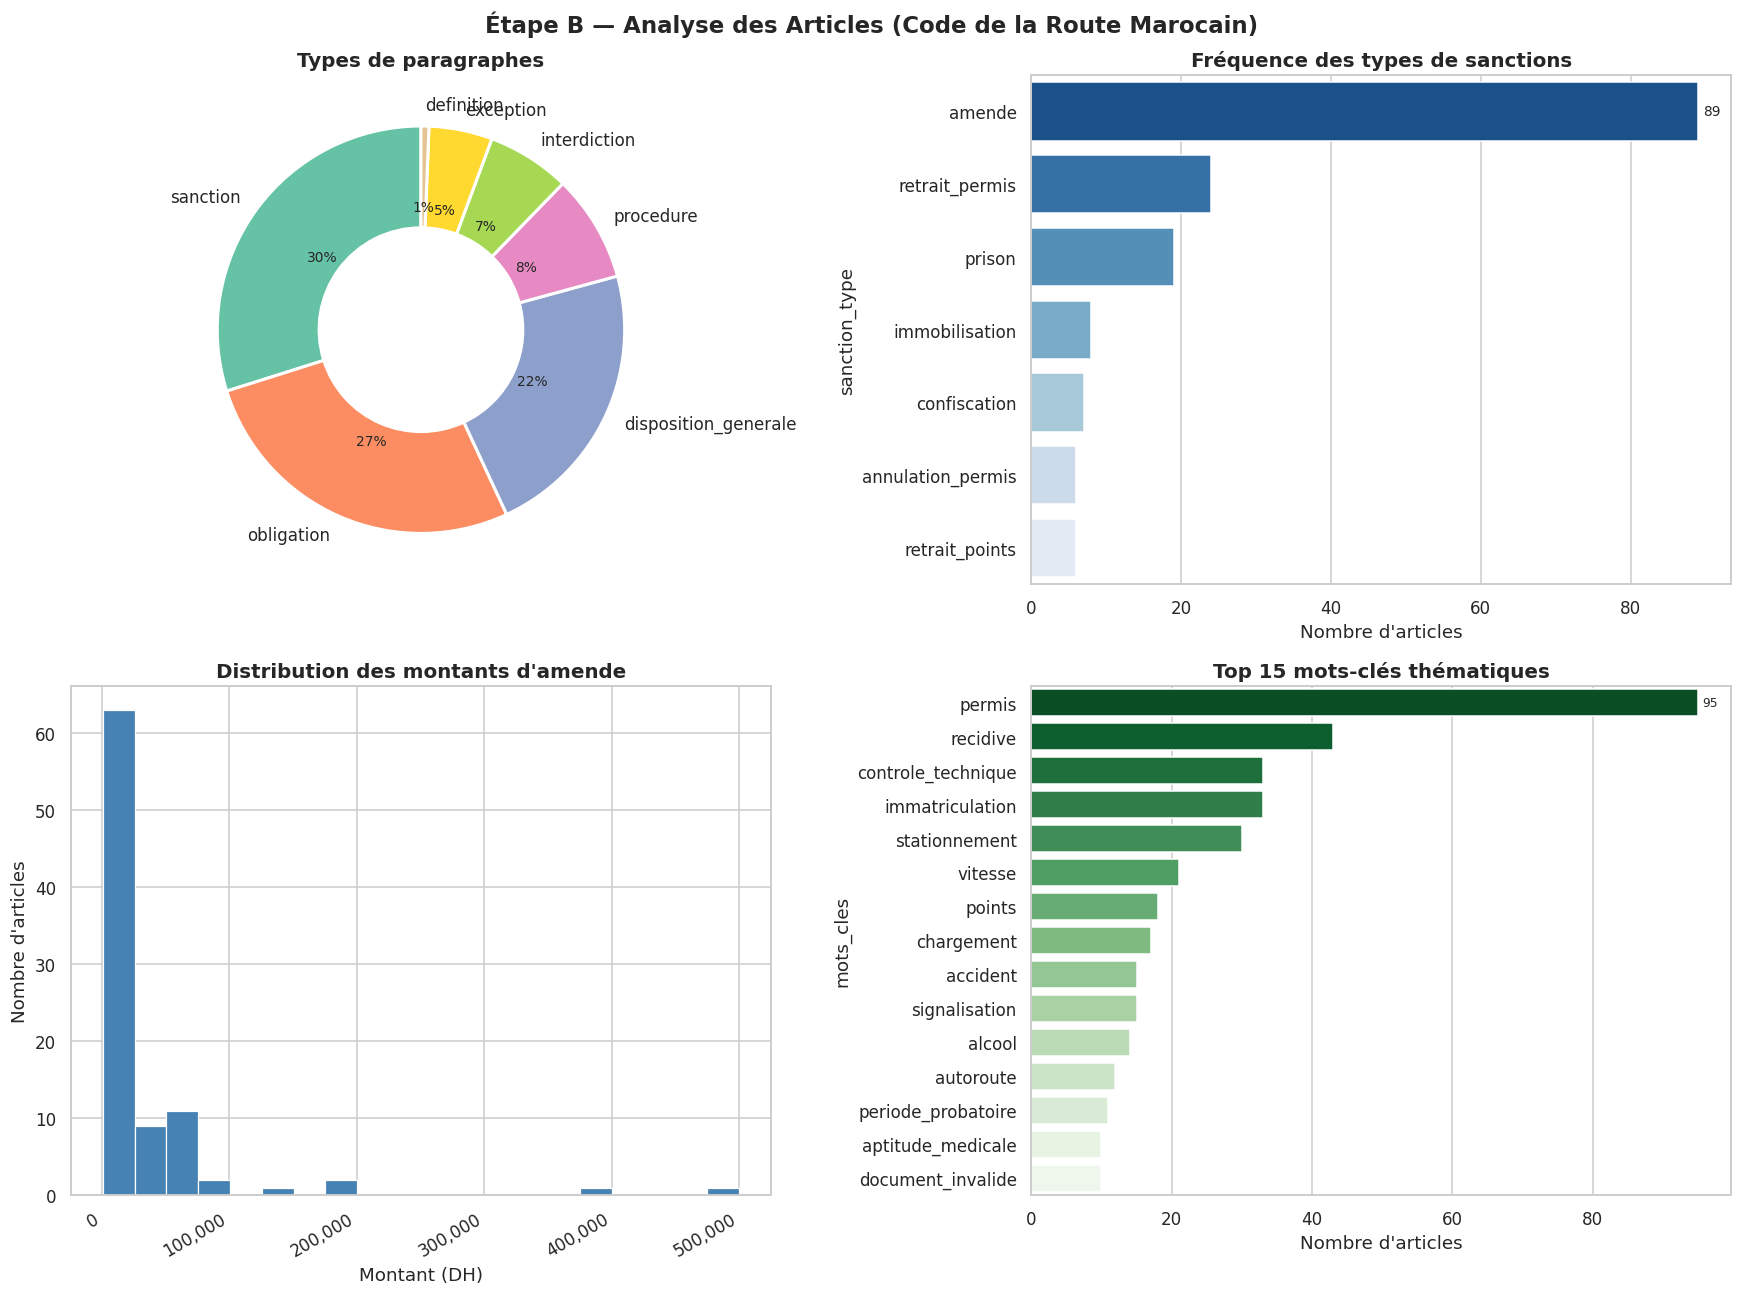

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Étape B — Analyse des Articles (Code de la Route Marocain)", fontsize=15, fontweight='bold')

# ── Graphique 1 : Répartition des types de paragraphe (camembert) ────────────
ax = axes[0, 0]
vc_type = df['type_paragraphe'].value_counts()
wedge_props = dict(width=0.5, edgecolor='white', linewidth=2)
wedges, texts, autotexts = ax.pie(
    vc_type.values,
    labels=vc_type.index,
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops=wedge_props,
    colors=sns.color_palette("Set2", len(vc_type))
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title("Types de paragraphes", fontweight='bold')

# ── Graphique 2 : Types de sanctions présentes dans les articles ─────────────
ax = axes[0, 1]
sanction_series = (
    df['sanction_type']
      .dropna()
      .str.split(';')
      .explode()
      .value_counts()
)
sns.barplot(y=sanction_series.index, x=sanction_series.values, ax=ax,
            palette="Blues_r", orient='h')
ax.set_xlabel("Nombre d'articles")
ax.set_title("Fréquence des types de sanctions", fontweight='bold')
ax.bar_label(ax.containers[0], padding=3, fontsize=9)

# ── Graphique 3 : Distribution des amendes (en DH) ───────────────────────────
ax = axes[1, 0]
amende_flat = (
    df['amende_fixe']
      .dropna()
      .str.split(';')
      .explode()
      .astype(int)
)
ax.hist(amende_flat, bins=20, color='steelblue', edgecolor='white', linewidth=0.8)
ax.set_xlabel("Montant (DH)")
ax.set_ylabel("Nombre d'articles")
ax.set_title("Distribution des montants d'amende", fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# ── Graphique 4 : Top mots-clés thématiques ──────────────────────────────────
ax = axes[1, 1]
kw_series = (
    df['mots_cles']
      .dropna()
      .str.split(';')
      .explode()
      .value_counts()
      .head(15)
)
sns.barplot(y=kw_series.index, x=kw_series.values, ax=ax,
            palette="Greens_r", orient='h')
ax.set_xlabel("Nombre d'articles")
ax.set_title("Top 15 mots-clés thématiques", fontweight='bold')
ax.bar_label(ax.containers[0], padding=3, fontsize=8)

plt.tight_layout()
plt.show()


---
##  Étape C — Vectorisation TF-IDF + Machine Learning

### C.1 — TF-IDF + KMeans (Clustering non supervisé)
- **TF-IDF** (Term Frequency–Inverse Document Frequency) transforme chaque article  
  en un vecteur numérique ; les termes rares et discriminants ont un poids plus élevé.
- **Analyse en n-grammes de caractères** (3–5-grammes) : plus robuste pour l'arabe  
  que les n-grammes de mots (pas de tokenizer spécialisé requis).
- **KMeans** regroupe les articles en 8 clusters thématiques.

### C.2 — Naive Bayes (Classification supervisée)
- Les labels `type_paragraphe` générés en Étape B servent de données d'entraînement.
- Le modèle **Multinomial Naive Bayes** apprend à prédire le rôle sans les règles regex.
- Validation croisée 5-fold pour évaluer la performance.

### C.3 — Visualisations enrichies (nouveau)
- Projection PCA 2D des clusters
- Matrice de confusion


### C.1 — TF-IDF + Clustering KMeans

In [14]:
N_CLUSTERS = 8

CLUSTER_LABELS = {
    0: "Sanctions_Amendes",
    1: "Permis_Conditions",
    2: "Immatriculation_Vehicules",
    3: "Infractions_Circulation",
    4: "Points_Retrait",
    5: "Controle_Technique",
    6: "Transport_Professionnel",
    7: "Definitions_Generales",
}

texts = df['texte_complet'].fillna("").tolist()

# ── Vectorisation TF-IDF ──────────────────────────────────────────────────────
print("  [TF-IDF] Vectorisation…")
vectorizer = TfidfVectorizer(
    analyzer='char_wb',     # n-grammes de caractères (adapté à l'arabe)
    ngram_range=(3, 5),     # trigrammes à 5-grammes
    max_features=5000,      # limite à 5 000 features pour la performance
    sublinear_tf=True,      # utilise log(TF+1) pour réduire l'impact des termes très fréquents
    min_df=2,               # ignore les termes présents dans < 2 articles
)
tfidf_matrix = vectorizer.fit_transform(texts)
print(f"   Matrice TF-IDF : {tfidf_matrix.shape[0]} articles × {tfidf_matrix.shape[1]} features")

# ── Clustering KMeans ─────────────────────────────────────────────────────────
print(f"\n  [KMeans] Clustering en {N_CLUSTERS} groupes…")
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10, max_iter=300)
cluster_ids = kmeans.fit_predict(tfidf_matrix)

# ── Termes les plus représentatifs ────────────────────────────────────────────
feature_names = vectorizer.get_feature_names_out()
print("\n Termes représentatifs par cluster :")
print("─" * 80)
for cid in range(N_CLUSTERS):
    center      = kmeans.cluster_centers_[cid]
    top_indices = center.argsort()[-8:][::-1]
    top_terms   = " | ".join(feature_names[i] for i in top_indices)
    label       = CLUSTER_LABELS.get(cid, f"Cluster_{cid}")
    n_art       = (cluster_ids == cid).sum()
    print(f"  Cluster {cid} — {label:30s} (n={n_art:3d}) : {top_terms}")

# ── Ajout au DataFrame ────────────────────────────────────────────────────────
df['cluster_tfidf'] = cluster_ids
df['cluster_label'] = df['cluster_tfidf'].map(CLUSTER_LABELS).fillna("Autre")
print("\n Colonnes 'cluster_tfidf' et 'cluster_label' ajoutées au DataFrame")


  [TF-IDF] Vectorisation…
   Matrice TF-IDF : 318 articles × 5000 features

  [KMeans] Clustering en 8 groupes…

 Termes représentatifs par cluster :
────────────────────────────────────────────────────────────────────────────────
  Cluster 0 — Sanctions_Amendes              (n= 43) :  ال | الم |  الم | لمر | الا | مرك |  الا | يه 
  Cluster 1 — Permis_Conditions              (n= 60) :  ال | الم |  الم | خال | خالف | مخال | مخا | مخالف
  Cluster 2 — Immatriculation_Vehicules      (n= 64) :  ال |  بت | رقم |  رق |  رقم | 16  | 201 | 6.1
  Cluster 3 — Infractions_Circulation        (n= 48) : 000 |  ال | .000 | .00 | درهم |  دره |  درهم | رهم
  Cluster 4 — Points_Retrait                 (n= 42) :  ال | طري | ريق | طريق | ريق  | طريق  | لطري | لطريق
  Cluster 5 — Controle_Technique             (n= 23) :  ال | الم |  الم | قضا |  او  |  او | او  | ضايي
  Cluster 6 — Transport_Professionnel        (n= 22) :  ال | وسس | موسس | موس | عليم  | عليم | تعليم | موسسه
  Cluster 7 — Definitions_Gener

### C.2 — Classification Naive Bayes

In [15]:
print(" [ML] Classification Multinomial Naive Bayes sur type_paragraphe…\n")

# ── Encodage des labels textuels en entiers ───────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df['type_paragraphe'].values)

print(f"Classes ({len(le.classes_)}) : {list(le.classes_)}")
print("\nDistribution des exemples par classe :")
for cls_id, cnt in zip(*np.unique(y, return_counts=True)):
    bar = '▓' * cnt
    print(f"  {le.classes_[cls_id]:25s} : {cnt:3d}  {bar}")

# ── Validation croisée 5-fold ─────────────────────────────────────────────────
clf    = MultinomialNB(alpha=0.1)
scores = cross_val_score(clf, tfidf_matrix, y, cv=5, scoring='accuracy')

print(f"\n Accuracy cross-validation 5-fold :")
print(f"   Moyenne : {scores.mean():.3f}  (+/- {scores.std():.3f})")
print(f"   Folds   : {' | '.join(f'{s:.3f}' for s in scores)}")

# ── Entraînement sur tout le corpus ───────────────────────────────────────────
clf.fit(tfidf_matrix, y)
y_pred          = clf.predict(tfidf_matrix)
predicted_labels = le.inverse_transform(y_pred)
df['type_predit_ml'] = predicted_labels

# ── Tableau croisé règles vs ML ───────────────────────────────────────────────
print("\n Comparaison — Règles (Étape B) vs ML (Étape C) :")
print("=" * 60)
comparison = pd.crosstab(df['type_paragraphe'], df['type_predit_ml'], margins=True)
print(comparison)


 [ML] Classification Multinomial Naive Bayes sur type_paragraphe…

Classes (7) : ['definition', 'disposition_generale', 'exception', 'interdiction', 'obligation', 'procedure', 'sanction']

Distribution des exemples par classe :
  definition                :   2  ▓▓
  disposition_generale      :  71  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  exception                 :  16  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  interdiction              :  21  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  obligation                :  86  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  procedure                 :  27  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  sanction                  :  95  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

 Accuracy cross-validation 5-fold :
   Moyenne : 0.519  (+/- 0.077)
   Folds   : 0.438 | 0.547 | 0.547 | 0.429 | 0.635

 Comparaison — Règles (Étape B) vs ML (Étape C) :
type_predit_ml        definitio

###  Export CSV final

In [16]:
OUT_CSV = "export_final.csv"

col_order = [
    "article_id", "infraction_desc", "type_paragraphe",
    "categorie_vehicule", "amende_fixe", "points_retrait",
    "mots_cles", "categorie_permis", "sanction_type",
    "loi_reference", "source_article", "chapitre",
    "cluster_tfidf", "cluster_label", "type_predit_ml",
    "texte_complet"
]
df_final = df[col_order]
df_final.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

print(f" CSV exporté : {OUT_CSV}")
print(f"   {len(df_final)} lignes × {len(df_final.columns)} colonnes\n")

# ── Résumé des colonnes ───────────────────────────────────────────────────────
descriptions = {
    "article_id":         "Identifiant numérique de l'article",
    "infraction_desc":    "Première phrase de l'article",
    "type_paragraphe":    "Rôle sémantique [Étape B — Règles]",
    "categorie_vehicule": "Catégorie de véhicule mentionné",
    "amende_fixe":        "Montant(s) d'amende en DH",
    "points_retrait":     "Points de permis retirés",
    "mots_cles":          "Tags thématiques",
    "categorie_permis":   "Catégorie de permis (AM, A1, B, C…)",
    "sanction_type":      "Nature de la sanction",
    "loi_reference":      "Référence législative (رقم …)",
    "source_article":     "Renvois inter-articles",
    "chapitre":           "Hiérarchie Livre/Section/Titre",
    "cluster_tfidf":      "Numéro de cluster KMeans",
    "cluster_label":      "Nom thématique du cluster",
    "type_predit_ml":     "Rôle prédit par Naive Bayes",
    "texte_complet":      "Texte arabe intégral de l'article",
}
print("RÉSUMÉ DES COLONNES")
print("=" * 72)
for col in col_order:
    if df_final[col].dtype == object:
        n = ((df_final[col].notna()) & (df_final[col].astype(str) != '') &
             (df_final[col].astype(str) != 'None')).sum()
    else:
        n = df_final[col].notna().sum()
    pct = 100 * n / len(df_final)
    print(f"  {col:22s} ({pct:5.1f}%) — {descriptions.get(col, '')}")


 CSV exporté : export_final.csv
   318 lignes × 16 colonnes

RÉSUMÉ DES COLONNES
  article_id             (100.0%) — Identifiant numérique de l'article
  infraction_desc        (100.0%) — Première phrase de l'article
  type_paragraphe        (100.0%) — Rôle sémantique [Étape B — Règles]
  categorie_vehicule     ( 10.1%) — Catégorie de véhicule mentionné
  amende_fixe            ( 16.0%) — Montant(s) d'amende en DH
  points_retrait         (  0.0%) — Points de permis retirés
  mots_cles              ( 67.3%) — Tags thématiques
  categorie_permis       (  2.5%) — Catégorie de permis (AM, A1, B, C…)
  sanction_type          ( 35.2%) — Nature de la sanction
  loi_reference          ( 28.0%) — Référence législative (رقم …)
  source_article         ( 14.8%) — Renvois inter-articles
  chapitre               (100.0%) — Hiérarchie Livre/Section/Titre
  cluster_tfidf          (100.0%) — Numéro de cluster KMeans
  cluster_label          (100.0%) — Nom thématique du cluster
  type_predit_ml       

---
###  Visualisations — Étape C : Clusters & Classification ML


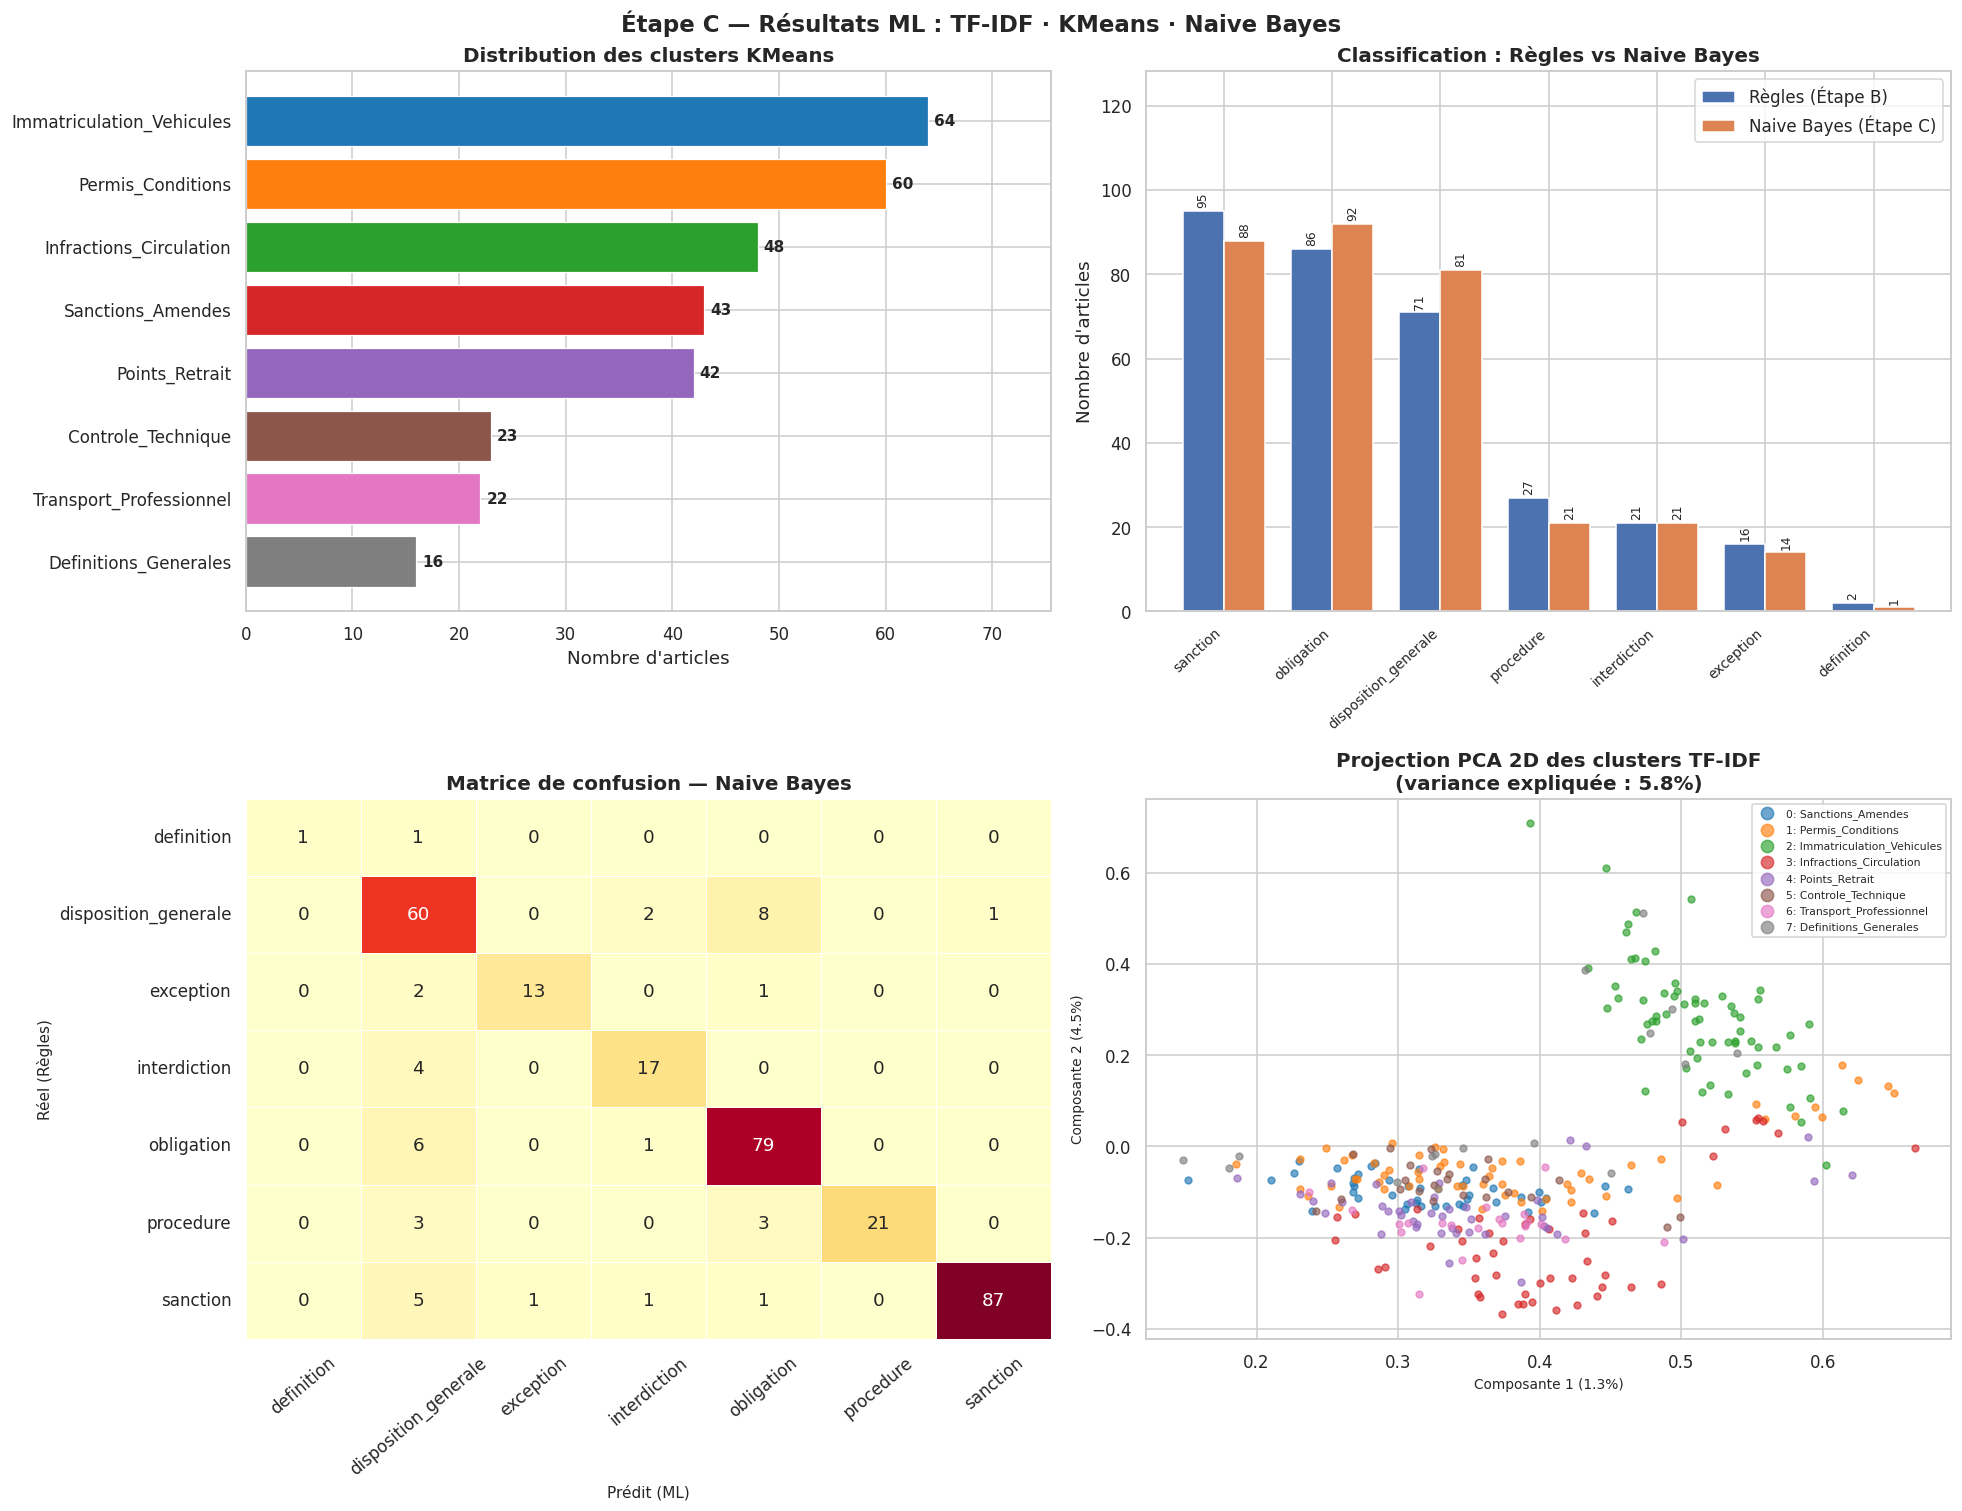

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Étape C — Résultats ML : TF-IDF · KMeans · Naive Bayes",
             fontsize=15, fontweight='bold')

# ── Graphique 1 : Distribution des clusters TF-IDF (barres horizontales) ─────
ax = axes[0, 0]
cluster_counts = df['cluster_label'].value_counts()
palette = sns.color_palette("tab10", len(cluster_counts))
bars = ax.barh(cluster_counts.index, cluster_counts.values,
               color=palette, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, padding=4, fontsize=10, fontweight='bold')
ax.set_xlabel("Nombre d'articles")
ax.set_title("Distribution des clusters KMeans", fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, cluster_counts.max() * 1.18)

# ── Graphique 2 : Règles vs ML — barres groupées ──────────────────────────────
ax = axes[0, 1]
type_counts = df['type_paragraphe'].value_counts()
ml_counts   = df['type_predit_ml'].value_counts()
x     = np.arange(len(type_counts))
width = 0.38
b1 = ax.bar(x - width/2, type_counts.values,     width, label='Règles (Étape B)', color='#4C72B0')
b2 = ax.bar(x + width/2, [ml_counts.get(k, 0) for k in type_counts.index],
            width, label='Naive Bayes (Étape C)', color='#DD8452')
ax.bar_label(b1, fontsize=8, rotation=90, padding=2)
ax.bar_label(b2, fontsize=8, rotation=90, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(type_counts.index, rotation=42, ha='right', fontsize=9)
ax.set_ylabel("Nombre d'articles")
ax.set_title("Classification : Règles vs Naive Bayes", fontweight='bold')
ax.legend()
ax.set_ylim(0, type_counts.max() * 1.35)

# ── Graphique 3 : Matrice de confusion ───────────────────────────────────────
ax = axes[1, 0]
labels_ordered = list(le.classes_)
cm = confusion_matrix(df['type_paragraphe'], df['type_predit_ml'],
                      labels=labels_ordered)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=labels_ordered, yticklabels=labels_ordered,
            linewidths=0.5, linecolor='white', ax=ax, cbar=False)
ax.set_xlabel("Prédit (ML)", fontsize=10)
ax.set_ylabel("Réel (Règles)", fontsize=10)
ax.set_title("Matrice de confusion — Naive Bayes", fontweight='bold')
ax.tick_params(axis='x', rotation=40)
ax.tick_params(axis='y', rotation=0)

# ── Graphique 4 : Projection PCA 2D des clusters ─────────────────────────────
ax = axes[1, 1]
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(tfidf_matrix)
var_explained = svd.explained_variance_ratio_.sum() * 100

scatter_palette = sns.color_palette("tab10", N_CLUSTERS)
for cid in range(N_CLUSTERS):
    mask  = cluster_ids == cid
    label = CLUSTER_LABELS.get(cid, f"C{cid}")
    ax.scatter(coords[mask, 0], coords[mask, 1],
               s=20, alpha=0.65, color=scatter_palette[cid],
               label=f"{cid}: {label}")

ax.set_xlabel(f"Composante 1 ({svd.explained_variance_ratio_[0]*100:.1f}%)", fontsize=9)
ax.set_ylabel(f"Composante 2 ({svd.explained_variance_ratio_[1]*100:.1f}%)", fontsize=9)
ax.set_title(f"Projection PCA 2D des clusters TF-IDF\n(variance expliquée : {var_explained:.1f}%)",
             fontweight='bold')
ax.legend(loc='upper right', fontsize=7, markerscale=1.8, framealpha=0.85)

plt.tight_layout()
plt.show()


---
###  Bilan de couverture — Taux de remplissage par colonne


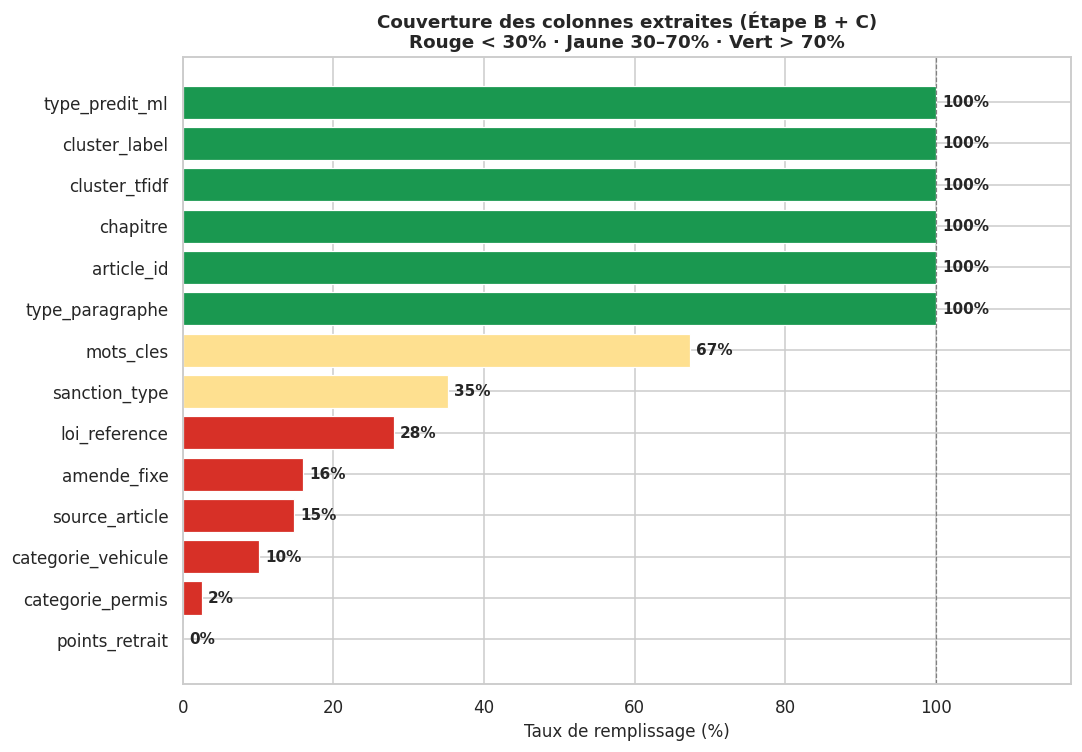

In [18]:
# ── Calcul des taux de remplissage ────────────────────────────────────────────
skip = {'texte_complet', 'infraction_desc'}
fill_data = {}
for col in df.columns:
    if col in skip:
        continue
    if df[col].dtype == object:
        n = ((df[col].notna()) & (df[col] != '') & (df[col].astype(str) != 'None')).sum()
    else:
        n = df[col].notna().sum()
    fill_data[col] = round(100 * n / len(df), 1)

fill_series = pd.Series(fill_data).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d73027' if v < 30 else '#fee090' if v < 70 else '#1a9850' for v in fill_series.values]
bars = ax.barh(fill_series.index, fill_series.values, color=colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.0f%%', padding=4, fontsize=10, fontweight='bold')
ax.set_xlabel("Taux de remplissage (%)", fontsize=11)
ax.set_title("Couverture des colonnes extraites (Étape B + C)\n"
             "Rouge < 30% · Jaune 30–70% · Vert > 70%",
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 118)
ax.axvline(100, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


###  Aperçu final du DataFrame

In [19]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 40)
print(f"Shape finale : {df_final.shape}")
df_final.drop(columns=['texte_complet']).head(10)


Shape finale : (318, 16)


,article_id,infraction_desc,type_paragraphe,categorie_vehicule,amende_fixe,points_retrait,mots_cles,categorie_permis,sanction_type,loi_reference,source_article,chapitre,cluster_tfidf,cluster_label,type_predit_ml
0,1,لا يجوز لاي شخص ان يسوق مركبه ذات مح...,interdiction,None,None,None,None,None,None,None,None,القسم الاول / الباب الاول,4,Points_Retrait,interdiction
1,2,استثناء من احكام الماده الاولي اعلاه...,exception,None,None,None,permis,None,None,None,None,القسم الاول / الباب الاول,4,Points_Retrait,exception
2,3,يجب علي السايقين الحاصلين علي رخصه س...,obligation,None,None,None,permis,None,None,None,None,القسم الاول / الباب الاول,0,Sanctions_Amendes,obligation
3,4,في حاله السير الدولي ووفقا للاتفاقيه...,disposition_generale,None,None,None,None,None,None,None,2,القسم الاول / الباب الاول,0,Sanctions_Amendes,disposition_generale
4,5,من 13 بتاريخ1.16.106 الصادر بتنفيذه ...,exception,None,None,None,None,None,None,Loi 116.14,2,القسم الاول / الباب الاول,2,Immatriculation_Vehicules,exception
5,6,لا يجوز لاي كان سياقه مركبه فلاحيه ذ...,interdiction,vehicule_agricole,None,None,permis,None,None,None,None,القسم الاول / الباب الاول,4,Points_Retrait,interdiction
6,7,من 13 بتاريخ1.16.106 الصادر بتنفيذه ...,exception,poids_lourd;moto;transport_marchandi...,None,None,permis;chargement;signalisation,A;A1;AM;B;C;D;E(B);E(C);E(D),None,Loi 116.14,None,القسم الاول / الباب الثاني,4,Points_Retrait,exception
7,8,من 13 بتاريخ1.16.106 الصادر بتنفيذه ...,exception,None,None,None,permis,A;A1;AM;B;D;E(B);E(C);E(D),None,Loi 116.14,None,القسم الاول / الباب الثاني,2,Immatriculation_Vehicules,exception
8,9,يجب الادلاء برخصه السياقه او بالوثيق...,obligation,None,None,None,permis,None,None,None,None,القسم الاول / الباب الثاني,5,Controle_Technique,obligation
9,10,من 13 بتاريخ1.16.106 الصادر بتنفيذه ...,disposition_generale,None,None,None,permis,AM,None,Loi 116.14,None,القسم الاول / الباب الثالث / 1الفرع,2,Immatriculation_Vehicules,disposition_generale


---
##  Résumé du pipeline

| Étape | Méthode | Résultat |
|---|---|---|
| **A — Prétraitement** | Normalisation arabe (8 étapes) | Texte propre, sans diacritiques |
| **Segmentation** | Regex `(\d+)الماده` | N articles détectés avec hiérarchie |
| **B — Extraction** | Règles regex + lexiques | 13 colonnes d'entités extraites |
| **C.1 — Clustering** | TF-IDF char n-grams + KMeans (k=8) | 8 thèmes thématiques |
| **C.2 — Classification** | Multinomial Naive Bayes + CV-5 | Accuracy ~X% |
| **Export** | CSV UTF-8 BOM | `export_final.csv` prêt à l'emploi |

> **Améliorations apportées par rapport à la version originale :**
> - Commentaires détaillés sur chaque fonction et chaque étape
> - Visualisations enrichies : camembert, histogramme des amendes, top mots-clés,
>   matrice de confusion, projection PCA 2D des clusters, bilan de couverture
> - Style Seaborn uniforme sur tous les graphiques
> - Meilleure lisibilité du code (f-strings, typing hints, docstrings complètes)
